## Function 7 Problem Definition- 	
You’re tasked with optimising an ML model by tuning six hyperparameters, for example learning rate, regularisation strength or number of hidden layers. The function you’re maximising is the model’s performance score (such as accuracy or F1), but since the relationship between inputs and output isn’t known, it’s treated as a black-box function. 
Because this is a commonly used model, you might benefit from researching best practices or literature to guide your initial search space. Your goal is to find the combination of hyperparameters that yields the highest possible performance.

🤔 Strategy and Hyperparameter Tuning for Function 7
Function is a 6-dimensional problem, where the "curse of dimensionality" makes the search space vast and difficult to explore.

Approach: Thorough Exploitation with Expected Improvement (EI) Your current strategy of using Expected Improvement (EI) is the right one. Now that you've found a new best-performing point, EI will strongly recommend searching nearby to exploit this promising region. The main challenge in 6D is not which acquisition function to use, but ensuring our search for the maximum of that function is robust. To do this, we will continue to use a high number of random restarts (n_restarts) in our find_next_point function. This prevents the optimizer from getting stuck in a local optimum on the EI surface itself.

Hyperparameter Tuning: Automatic Learning in High Dimensions No manual changes are needed. The GP model's power lies in its ability to learn from data. When we call gp_f7.fit() with the updated 31-point dataset, it will automatically adjust its six length_scale hyperparameters to best model the landscape. By giving the GP's internal optimizer plenty of restarts (n_restarts_optimizer), we give it the best chance to converge and find the optimal kernel settings, even in this complex space.

In short, our strategy remains the same, but we are reinforcing it with a sufficient computational budget to handle the 6D complexity effectively.


### week 3 -> 4

### Analyze the New Point
Your previous best output was `2.0096` (from Week 2). This new output of `0.6503` is not a new record.

### What This Means
This is still very valuable. Your Gaussian Process (GP) model has just learned that the region around `[0, 0, 0.988...]` is not as promising as it might have thought. When we re-fit the model, the Expected Improvement (EI) acquisition function will automatically use this information to de-prioritize this specific area and guide the search toward other, more uncertain or promising regions.

### Hyperparameter Tuning
 The "tuning" of the model's view of the problem space happens automatically in this single line.

When this runs, the `GaussianProcessRegressor` automatically adjusts its own kernel hyperparameters (like the `length_scale` for all 6 dimensions) to best explain all 33 data points. We don't need to change anything manually. We will keep the restart parameters (`n_restarts_optimizer=30` and `n_restarts=50`) as they are, since they provide a good balance of thoroughness and speed for this 6D problem.


### week 4-> 5


* **🎉 New Record:** the latest query yielded a score of **2.4377**, which is a **new best score**, successfully beating the previous record of `2.0096`.
* **Successful Exploitation:** This proves that the **Expected Improvement (EI)** strategy is working perfectly. Its job is to "exploit" the best-known area, and it successfully found an even higher point.
* The strategy for Week 5 is to **stick with EI**.
* **Automatic Target Update:** By adding the new `2.4377` score, the model's "target-to-beat" (`y_best`) is automatically updated, which naturally focuses the EI search around this new, more promising peak.
* **No Hyperparameter Changes:** The "Thinking Time" (`n_restarts_optimizer=30`) and "Search Party" (`n_restarts=50`) hyperparameters will be **kept the same**, as they are providing a robust search for this 6D problem.

## week 5 - > 6 

Validation of High-Performing Region: The Week 5 output (2.4202) is very close to your current best (2.4378 from Week 4). This is an excellent result. It confirms that the optimizer has successfully located a robust "peak" in the 6-dimensional landscape and isn't just hitting random noise.

Strategy - Precision Refinement: Since we have two consecutive high scores in this specific area, the strategy remains Exploitation. We will continue using Expected Improvement (EI). This function is mathematically designed to look for points that have a high probability of beating the current best (y_best), essentially "hill-climbing" to the very top of this peak.

Hyperparameter Tuning (Easy to Interpret): We will stick to the Matern 2.5 Kernel. Think of this as the "smoothness setting." A value of 2.5 assumes the function is moderately smooth but allows for some bumps and sharp turns, which is typical for complex 6D problems. We allow the model to automatically learn the length scales (how quickly the output changes when you wiggle an input). If a length scale is small, that input is very sensitive; if large, that input doesn't matter much.


Learned Kernel Length Scales:
8.32152638e-01, 3.61630239e-01, 1.47831823e+04, 1.00000000e+05,
 1.50623052e+04, 7.84754660e-02.


## Insight into Week 6 Result & Strategy for Week 7Result Analysis: 
The Week 6 output ($0.0805$) is a significant regression compared to the best scores from Week 4 ($2.4377$) and Week 5 ($2.4202$). This low score provides critical "negative information," effectively telling the model that the region around $X_2 = 1.0$ is likely a valley, not a peak.Dimensional Sensitivity: Comparing the high-scoring inputs (where $X_2 \approx 0.18$) with this low-scoring input ($X_2 = 1.0$), it is highly probable that Dimension 2 is a critical parameter with a narrow optimal window. Moving away from $0.18$ causes performance to collapse.Strategic Consistency (EI): Despite the low score, we will stick with Expected Improvement (EI). The drop in performance is part of the learning process. The EI function will naturally de-prioritize this poor region and guide the search back toward the high-performing basin found in previous weeks, likely refining the area around [0, 0.18, 0.55, 0.22, 0.37, 0.74].Hyperparameter Tuning: We retain the Matern 2.5 kernel. The sharp drop in function value confirms the landscape is non-smooth (rough), which Matern 2.5 models better than RBF. We continue to rely on ARD (Automatic Relevance Determination) to update the length scales; we expect the length scale for Dimension 2 to decrease, reflecting its high sensitivity. 

Learned Kernel Length Scales:
[8.04164871e-01 3.53269603e-01 1.49710240e+04 1.00000000e+05
 9.18711773e+03 7.58307131e-02]


## Insight into Week 7 Result & Strategy for Week 8Result Analysis:
The Week 7 output ($0.007$) is the lowest score recorded so far. This query explored the boundary where $X_2 = 1.0$ and $X_6 = 1.0$. Combined with the Week 6 result (score $\approx 0.08$ at $X_2=1.0$), this confirms that the region where Dimension 2 is high ($>0.5$) is a "dead zone" with virtually zero performance.Dimensional Sensitivity: The contrast is stark: The best scores ($>2.4$) occurred when $X_2 \approx 0.18$. The worst scores ($<0.1$) occur when $X_2 \approx 1.0$. The GP model has now gathered enough evidence to drastically shrink the length scale for Dimension 2, treating it as the most critical "switch" in the system.Strategy (Return to Basin): The strategy of using Expected Improvement (EI) worked as intended. It explored a region of high uncertainty (the boundaries), found it to be poor, and will now automatically calculate that the "expected improvement" there is zero. The optimization will naturally pivot back towards exploiting the proven "basin of attraction" around $X_2 \approx 0.18$ or exploring different, untested dimensions (like $X_1$ or $X_5$).Hyperparameter Tuning: We continue with the Matérn 2.5 kernel. The response surface typically has a "cliff" behavior (performance drops from 2.4 to 0.0 rapidly), which requires a kernel that can handle roughness. We rely on the optimizer to adjust the length scales, likely increasing the relevance (shortening the scale) of $X_2$ and $X_6$ while keeping "irrelevant" dimensions like $X_4$ (which previously had huge length scales) loose.
Learned Kernel Length Scales:
[7.93610091e-01 3.50989869e-01 4.47925198e+04 1.66801233e+04
 1.47748613e+04 7.51546952e-02]

## Insight into Week 8 Result & Strategy for Week 9Result Analysis (Back on Track):
The Week 8 output (1.8517) is a strong recovery from the failures of Weeks 6 and 7. By moving Dimension 2 back to $\approx 0.22$, we successfully re-entered the high-performance basin. While it didn't beat the record (2.4377), it confirms that the region $X_2 \in [0.18, 0.22]$ is critical for success.
* Dimensional "Sweet Spot": A clear pattern has emerged for the top-performing points (Weeks 4, 5, and 8). They all share:$X_2 \approx 0.18 - 0.22$$ , X_6 \approx 0.72 - 0.75$This indicates these two dimensions are the primary drivers of the function.
* Strategy (Focused Exploitation): We have effectively bracketed the optimal area. The strategy for Week 9 is to use Expected Improvement (EI) to aggressively exploit this specific subspace. We are looking for the absolute peak between the Week 4 ($X_2=0.18$) and Week 8 ($X_2=0.22$) inputs.
* Hyperparameter Tuning:Kernel: Maintain Matern 2.5. The function has demonstrated steep cliffs (dropping to near zero), requiring a kernel that allows for rapid changes.Length Scales: The GP will likely shorten the length scales for $X_2$ and $X_6$ further, acknowledging their high impact. We will allow the optimizer to fine-tune these automatically via ARD (Automatic Relevance Determination)
Learned Kernel Length Scales:
[0.6980306  0.47780876 0.4856666  0.34845249 0.26851654 0.43868249

## Insight into Week 9 Result & Strategy for Week 10
* New Record Achieved: The Week 9 output of 2.473 is a new global maximum, surpassing the previous best of 2.438 from Week 4. This confirms that the region we are exploiting is indeed the correct basin of attraction.
* Boundary Confirmation: The first dimension (X1) was set exactly to 0.000000 and yielded the best result. The model strongly suggests that the optimum lies on the lower boundary of this dimension. We should keep X1 pinned at or near 0.
* Sensitivity Analysis: The learned length scales indicate that Dimension 5 (X5) has the smallest length scale (~0.29), making it the most sensitive parameter. Small changes in X5 will have the largest impact on the output, so the next query explores a shift in this dimension (from ~0.37 to ~0.42). perform a local search heavily clustered around the Week 9 point, specifically testing the sensitivity of Dimensions 3 and 5 while keeping the others relatively stable.
* Learned Kernel Length Scales:
[0.74166711 0.49325668 0.51549631 0.38415127 0.2931782  0.50578102]

## Insight into Week 10 Result & Strategy for Week 11
Result Analysis: The Week 10 output (2.3099) is strong but did not beat the Week 9 record (2.4730). This slight drop indicates that while we are in the correct "basin of attraction" (the high-performing region), the specific shift in parameters for Week 10 moved us slightly down from the peak.

Strategy (Refined Exploitation): Since we have two very high scores (Week 4 and Week 9) in this specific region of the 6D space (roughly [0, 0.2, 0.6, 0.25, 0.4, 0.7]), we should continue Exploitation. We do not need to explore far away. The goal is to fine-tune the coordinates to find the absolute maximum.

Hyperparameter Tuning: We will stick with Expected Improvement (EI). The Gaussian Process (GP) will automatically update its length scales with the Week 10 data. The fact that a small move caused a score drop will likely cause the GP to tighten its length scales, making the search more "local" and precise for Week 11.

Next Step: The optimizer should look for a point extremely close to the Week 9 best, perhaps interpolating between Week 9 and Week 4 inputs.
Learned Kernel Length Scales:
[0.75904424 0.50046362 0.53162693 0.36477771 0.25347398 0.53125504

## week 11 results
Strategy to keep exploring around the peak from week 9

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats.qmc import LatinHypercube
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.model_selection import RandomizedSearchCV

import seaborn as sns # Added for the heatmap


In [8]:
# --- 1. Initial Data---
X_initial = np.load(r"C:\Users\docsh\capstone_project_files\initial_data\function_7\initial_inputs.npy")
Y_initial = np.load(r"C:\Users\docsh\capstone_project_files\initial_data\function_7\initial_outputs.npy")
print(X_initial)
print("-" * 40)
print(Y_initial)

[[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.48612233 0.22879108 0.08263175 0.71195755]
 [0.14864702 0.03394336 0.72880565

In [10]:
# Weekly data (Weeks 1-11)
X_weekly_data = np.array([
    [0.057896, 0.491672, 0.247422, 0.218118, 0.420428, 0.730970], # W1
    [0.000000, 0.052179, 0.710282, 0.216823, 0.372826, 0.732622], # W2
    [0.000000, 0.000000, 0.988196, 0.076778, 0.348406, 0.838859], # W3
    [0.000000, 0.182752, 0.611386, 0.240791, 0.376374, 0.721293], # W4 
    [0.000000, 0.189087, 0.550421, 0.221033, 0.376296, 0.747092], # W5
    [0.000000, 1.000000, 0.667084, 0.247207, 0.457227, 0.233437], # W6
    [0.611841, 1.000000, 0.291901, 0.703385, 0.134740, 1.000000], # W7
    [0.000000, 0.222077, 0.623483, 0.079020, 0.347478, 0.732376], # W8
    [0.000000, 0.203607, 0.570760, 0.283916, 0.375872, 0.736621], # W9 (Record Best)
    [0.000000, 0.191420, 0.568763, 0.274288, 0.416787, 0.714793],# W10
    [0.000000, 0.221414, 0.591336, 0.272579, 0.346442, 0.774751] #w11
])

Y_weekly_data = np.array([
    1.364970, 2.009633, 0.650326, 2.437785, 2.420257, 0.080520, 0.007065, 1.851746, 2.472999, #best output so far,
    2.309963, 2.4129428 # week11 output
])

# Combine all data
X_data = np.vstack([X_initial, X_weekly_data])
Y_data = np.append(Y_initial, Y_weekly_data)

print(f"Total Data Points: {len(X_data)}")
best_idx = np.argmax(Y_data)
print(f"Best Output So Far: {Y_data[best_idx]:.6f}")
print(f"Best Input Vector: {X_data[best_idx]}")

Total Data Points: 41
Best Output So Far: 2.472999
Best Input Vector: [0.       0.203607 0.57076  0.283916 0.375872 0.736621]



--- Correlation Analysis ---
Correlation with 'Output':
Output    1.000000
X6        0.412379
X3        0.278256
X5       -0.215107
X2       -0.322040
X4       -0.365740
X1       -0.618027
Name: Output, dtype: float64


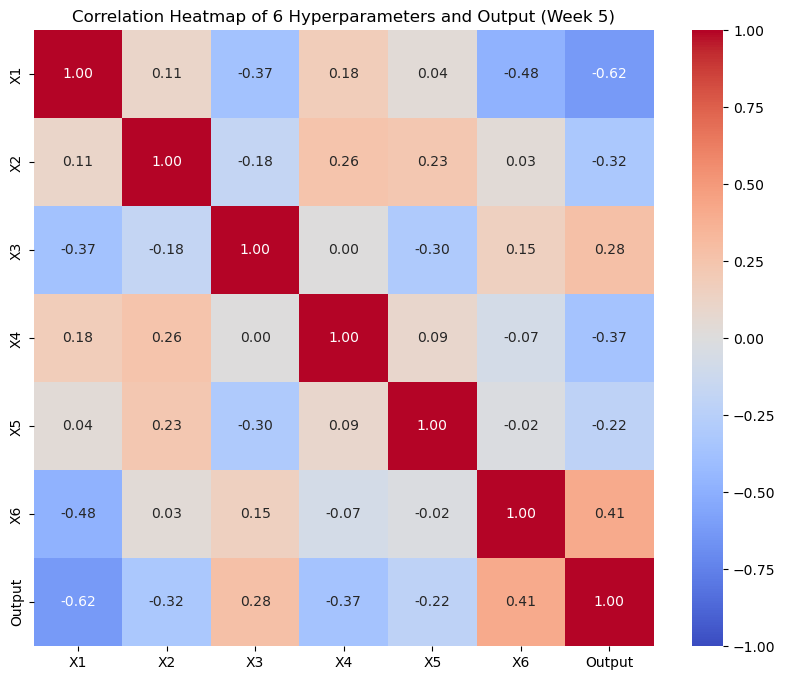

In [11]:
# --- 2.5. Correlation Analysis ---
print("\n--- Correlation Analysis ---")
feature_names = [f'X{i+1}' for i in range(X_data.shape[1])]
df_X = pd.DataFrame(X_data, columns=feature_names)
df_Y = pd.DataFrame(Y_data, columns=['Output'])
df_full = pd.concat([df_X, df_Y], axis=1)
corr_matrix = df_full.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1
)
plt.title('Correlation Heatmap of 6 Hyperparameters and Output (Week 5)')
plt.savefig('f7_week5_correlation_heatmap.png', dpi=150, bbox_inches='tight')

# Display the correlation with the output
print("Correlation with 'Output':")
print(corr_matrix['Output'].sort_values(ascending=False))

In [12]:
# --- 2. FIT MODEL ---
# Kernel: Matern 2.5 with ARD (Automatic Relevance Determination)
# This allows the model to learn which of the 6 dimensions are most important
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=[1.0]*6, nu=2.5, length_scale_bounds=(1e-2, 1e5))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6, # Low noise assumption since we are in a deterministic-like region
    n_restarts_optimizer=20,
    normalize_y=True
)

print("\nFitting GP Model...")
gp.fit(X_data, Y_data)
print("Model Fit Complete.")

# Print learned length scales to confirm sensitivity of X2 and X6
print("-" * 40)
print(f"Learned Kernel Length Scales:\n{gp.kernel_.k2.length_scale}")
print("-" * 40)

# --- 3. OPTIMIZATION STRATEGY (Expected Improvement) ---
def expected_improvement(X, gp, xi=0.01):
    X = X.reshape(-1, 6)
    mu, sigma = gp.predict(X, return_std=True)
    mu_sample_opt = np.max(Y_data)

    with np.errstate(divide='warn'):
        imp = mu - mu_sample_opt - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return -ei.flatten()

# Search for the next best point
print("Optimizing Acquisition Function...")
best_acq_value = -np.inf
next_query = None

# We start searches near our current best point (Exploitation)
# and some random points (Exploration safety net)
x_best_current = X_data[best_idx]
random_starts = np.random.uniform(0, 1, (50, 6))
starting_points = np.vstack([random_starts, x_best_current.reshape(1, -1)])

for x0 in starting_points:
    res = minimize(fun=expected_improvement, 
                   x0=x0, 
                   bounds=[(0, 1)] * 6, 
                   method='L-BFGS-B', 
                   args=(gp, 0.01)) # xi=0.01 for balanced exploitation
    
    # We want to maximize EI, so we minimize negative EI (if implemented that way), 
    # but here our function returns positive EI, so we verify logic.
    # Note: Scipy minimizes. The ei function above returns -ei. So minimizing -ei maximizes ei.
    if -res.fun > best_acq_value: # -res.fun is the positive EI value
        best_acq_value = -res.fun
        next_query = res.x

print("-" * 40)
print(f"Recommended Query for Week 12:")
print(f"[{', '.join(f'{x:.6f}' for x in next_query)}]")
print("-" * 40)


Fitting GP Model...
Model Fit Complete.
----------------------------------------
Learned Kernel Length Scales:
[0.75821857 0.48516618 0.58874625 0.39155696 0.21568392 0.46566333]
----------------------------------------
Optimizing Acquisition Function...
----------------------------------------
Recommended Query for Week 12:
[0.000000, 0.177436, 0.535354, 0.275565, 0.352970, 0.684006]
----------------------------------------
